# Can Day Trading Really Be Profitable?

Reproduction of Zarattini & Aziz, [*Can Day Trading Really Be Profitable?*](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4416622): the
5-minute opening range breakout on QQQ and TQQQ, January 2016 to February 2023.

The strategy enters at the open of the first bar after the 5-minute opening
range, long if the range closed up and short if it closed down. The stop is at
the opposite extreme of the range, the target at 10R, and any position still open
is liquidated at the close. Each trade risks 1% of the account, capped at 4x
leverage.

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from firstrate_data import AssetType, Store
from matplotlib.dates import DateFormatter, YearLocator
from matplotlib.ticker import FuncFormatter

from orb.engine import BacktestEngine
from orb.portfolio import Portfolio
from orb.results import buy_and_hold_balance
from orb.strategy import ORBStrategy

In [2]:
# pg 9, table 1
BACKTEST_START = date(2016, 1, 1)
BACKTEST_END = date(2023, 2, 17)
STARTING_BALANCE = 25_000.0
COMMISSION_PER_SHARE = 0.0005
ORB_COLOR = "#111111"
BENCHMARK_COLOR = "#c81e1e"
UNCONSTRAINED_ORB_COLOR = "#4c8c2b"
TQQQ_BENCHMARK_COLOR = "#3aa8c1"

## Figure 2

The ORB portfolio against buy & hold on QQQ.

In [3]:
store = Store.from_env()

strategy = ORBStrategy(
    opening_range_len_1_min_bars=5,
    daily_atr_percentage=0.10,
    wait_for_breakout=False,
    apply_eligibility_criteria=False,
    stop_at_opening_range_extreme=True,
    tp_units_of_risk_r=10.0,
)
portfolio = Portfolio(
    starting_balance=STARTING_BALANCE,
    commission_per_share=COMMISSION_PER_SHARE,
)

qqq_engine = BacktestEngine(
    store=store,
    strategy=strategy,
    portfolio=portfolio,
    asset_type=AssetType.ETF,
    tickers=("QQQ",),
    start=BACKTEST_START,
    end=BACKTEST_END,
)
result = qqq_engine.run()
print("final balance:", qqq_engine.portfolio.balance)
result.elapsed_time

final balance: 174638.9959099039


datetime.timedelta(microseconds=883893)

In [4]:
result.total_positions

1780

There are 1,795 trading sessions between `BACKTEST_START` and `BACKTEST_END`, and
the paper reports one trade per session. We open 1,780: 14 sessions had a doji
opening range (`open == close`), and on 2020-03-16 the bar after the opening range
opened below the range low, past its own stop.

In [5]:
def orb_balance(portfolio: Portfolio) -> pl.DataFrame:
    return (
        qqq_buy_and_hold.select("session")
        .join(portfolio.equity_curve(), on="session", how="left")
        .select(
            "session",
            balance=pl.col("balance").forward_fill().fill_null(STARTING_BALANCE),
        )
    )


qqq_buy_and_hold = buy_and_hold_balance("QQQ", end=BACKTEST_END)
orb_qqq_balance = orb_balance(qqq_engine.portfolio)

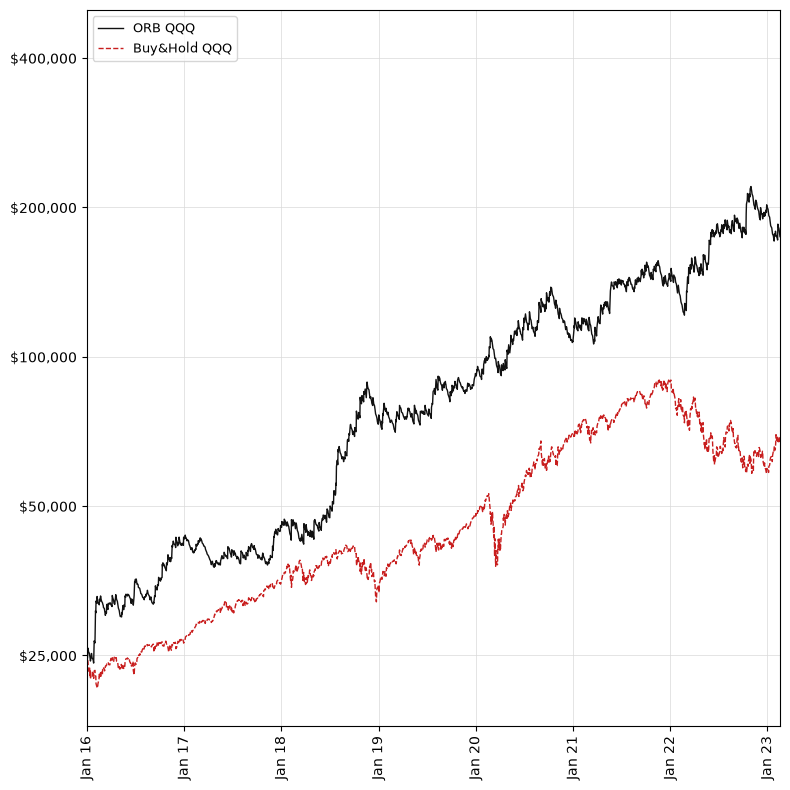

In [6]:
figure, axes = plt.subplots(figsize=(8, 8))

axes.plot(
    orb_qqq_balance["session"],
    orb_qqq_balance["balance"],
    color=ORB_COLOR,
    linewidth=1,
    label="ORB QQQ",
)
axes.plot(
    qqq_buy_and_hold["session"],
    qqq_buy_and_hold["balance"],
    color=BENCHMARK_COLOR,
    linewidth=1,
    linestyle="--",
    label="Buy&Hold QQQ",
)

axes.set_yscale("log")
axes.set_yticks([25_000, 50_000, 100_000, 200_000, 400_000])
axes.yaxis.set_major_formatter(FuncFormatter(lambda balance, _: f"${balance:,.0f}"))
axes.minorticks_off()
axes.set_ylim(18_000, 500_000)
axes.set_xlim(BACKTEST_START, BACKTEST_END)
axes.xaxis.set_major_locator(YearLocator())
axes.xaxis.set_major_formatter(DateFormatter("%b %y"))
axes.tick_params(axis="x", labelrotation=90)
axes.grid(color="0.85", linewidth=0.5)
axes.set_axisbelow(True)
axes.legend(loc="upper left", fontsize=9)

figure.tight_layout()
plt.show()

In [7]:
SESSIONS_A_YEAR = 252


def session_returns(balance: pl.Series) -> np.ndarray:
    curve = np.concatenate([[STARTING_BALANCE], balance.to_numpy()])
    return curve[1:] / curve[:-1] - 1


orb_returns = session_returns(orb_qqq_balance["balance"])
benchmark_returns = session_returns(qqq_buy_and_hold["balance"])

growth = orb_qqq_balance["balance"][-1] / STARTING_BALANCE
irr = growth ** (SESSIONS_A_YEAR / len(orb_returns)) - 1
volatility = orb_returns.std(ddof=1) * np.sqrt(SESSIONS_A_YEAR)
beta, alpha_a_session = np.polyfit(benchmark_returns, orb_returns, 1)

pl.DataFrame(
    {
        "Metric": ["Total Return", "IRR", "Sharpe Ratio", "Alpha", "Beta"],
        "ORB QQQ": [
            f"{growth - 1:.1%}",
            f"{irr:.1%}",
            f"{irr / volatility:.2f}",
            f"{alpha_a_session * SESSIONS_A_YEAR:.1%}",
            f"{beta:.2f}",
        ],
        "Paper": ["675%", "31%", "1.12", "33%", "~0"],
    }
)

Metric,ORB QQQ,Paper
str,str,str
"""Total Return""","""598.6%""","""675%"""
"""IRR""","""31.4%""","""31%"""
"""Sharpe Ratio""","""1.08""","""1.12"""
"""Alpha""","""32.0%""","""33%"""
"""Beta""","""-0.04""","""~0"""


Our ending balance falls short of the paper's $192,806, but the rest of the table
is close, and buy & hold on QQQ ends at $67,307, like the paper.

The residual gap is probably caused by the data. An [article](https://concretumgroup.com/backtesting-data-quality-can-your-data-provider-be-trusted/)
by the same authors measures how far two vendors' 1-minute bars for the same
ticker and session drift apart.

## Figure 5

Four curves: the ORB on QQQ freed of the 4x leverage cap (pg. 12), the ORB on
TQQQ under the same 4x cap, and the two passive benchmarks.

Unconstrained QQQ grows 1,245% against the paper's 1,630%, and TQQQ 1,492%
against 1,485%.

The store has only unadjusted ETF bars, and TQQQ split 2:1 in Jan 2017, 3:1 in
May 2018, 2:1 in Jan 2021 and 2:1 in Jan 2022, so the buy & hold curve compounds
session returns with the splits divided out. The backtest itself reads unadjusted
bars, as the paper does (pg. 8): each session stands on its own.

In [8]:
unconstrained_qqq_engine = BacktestEngine(
    store=store,
    strategy=strategy,
    portfolio=Portfolio(
        starting_balance=STARTING_BALANCE,
        commission_per_share=COMMISSION_PER_SHARE,
        max_leverage=float("inf"),
    ),
    asset_type=AssetType.ETF,
    tickers=("QQQ",),
    start=BACKTEST_START,
    end=BACKTEST_END,
)
tqqq_engine = BacktestEngine(
    store=store,
    strategy=strategy,
    portfolio=Portfolio(
        starting_balance=STARTING_BALANCE,
        commission_per_share=COMMISSION_PER_SHARE,
    ),
    asset_type=AssetType.ETF,
    tickers=("TQQQ",),
    start=BACKTEST_START,
    end=BACKTEST_END,
)

for engine in (unconstrained_qqq_engine, tqqq_engine):
    engine.run()
    print(engine.tickers, "final balance:", engine.portfolio.balance)

('QQQ',) final balance: 336301.2384242092


('TQQQ',) final balance: 397957.27778159454


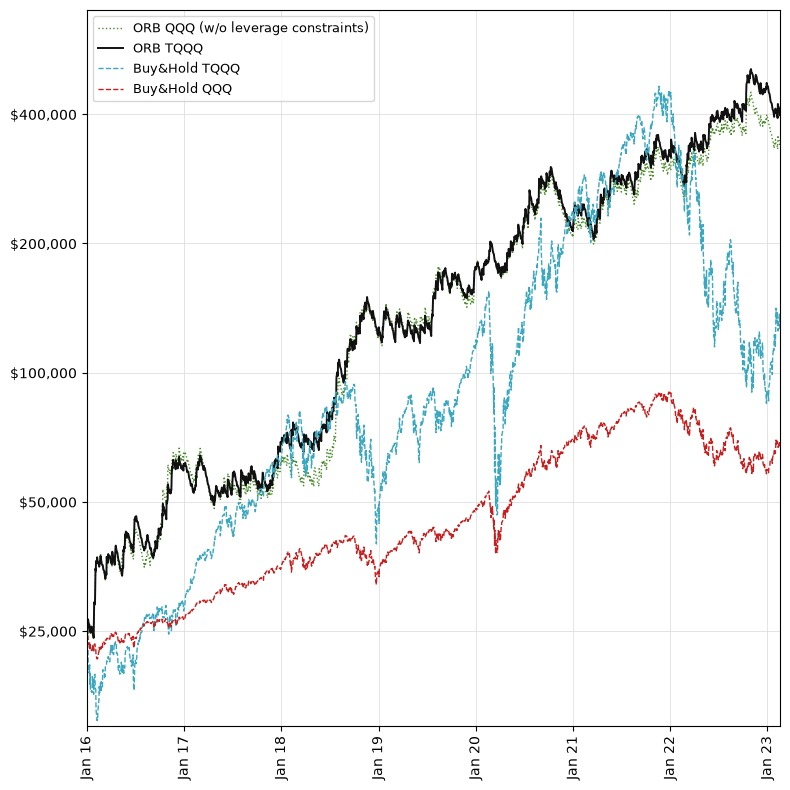

In [9]:
unconstrained_orb_qqq_balance = orb_balance(unconstrained_qqq_engine.portfolio)
orb_tqqq_balance = orb_balance(tqqq_engine.portfolio)
tqqq_buy_and_hold = buy_and_hold_balance("TQQQ", end=BACKTEST_END)

figure, axes = plt.subplots(figsize=(8, 8))

axes.plot(
    unconstrained_orb_qqq_balance["session"],
    unconstrained_orb_qqq_balance["balance"],
    color=UNCONSTRAINED_ORB_COLOR,
    linewidth=1,
    linestyle=":",
    label="ORB QQQ (w/o leverage constraints)",
)
axes.plot(
    orb_tqqq_balance["session"],
    orb_tqqq_balance["balance"],
    color=ORB_COLOR,
    linewidth=1.4,
    label="ORB TQQQ",
)
axes.plot(
    tqqq_buy_and_hold["session"],
    tqqq_buy_and_hold["balance"],
    color=TQQQ_BENCHMARK_COLOR,
    linewidth=1,
    linestyle="--",
    label="Buy&Hold TQQQ",
)
axes.plot(
    qqq_buy_and_hold["session"],
    qqq_buy_and_hold["balance"],
    color=BENCHMARK_COLOR,
    linewidth=1,
    linestyle="--",
    label="Buy&Hold QQQ",
)

axes.set_yscale("log")
axes.set_yticks([25_000, 50_000, 100_000, 200_000, 400_000])
axes.yaxis.set_major_formatter(FuncFormatter(lambda balance, _: f"${balance:,.0f}"))
axes.minorticks_off()
axes.set_ylim(15_000, 700_000)
axes.set_xlim(BACKTEST_START, BACKTEST_END)
axes.xaxis.set_major_locator(YearLocator())
axes.xaxis.set_major_formatter(DateFormatter("%b %y"))
axes.tick_params(axis="x", labelrotation=90)
axes.grid(color="0.85", linewidth=0.5)
axes.set_axisbelow(True)
axes.legend(loc="upper left", fontsize=9)

figure.tight_layout()
plt.show()